In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# DenseNet121 (Chandrasekaran)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import os
import random
import numpy as np

# --- ⚙️ Parameter Settings (Adapted from Context) ---
# Core reproducibility settings
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Training configuration
LEARNING_RATE = 2e-4  # AdamW optimizer LR
BATCH_SIZE = 16
EPOCHS = 25
MODEL_NAME = "DenseNet121" # The required model architecture

# Dataset configuration
# The path where your 'positive_xx.jpg' and 'negative_yy.jpg' images are stored
IMAGE_DIR = "/kaggle/input/musait/basket_unique" 
NUM_CLASSES = 3 # 'negative' and 'positive'

# --- 🛠️ Reproducibility Function ---
def set_seed(seed):
    """Sets a fixed seed for reproducibility across all relevant libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # For deterministic behavior
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Set seed to {SEED} for reproducibility.")

class SentimentImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png') or f.endswith('.jpeg') or f.endswith('.JPG')]
        
        # --- 🔄 Updated Label Map for 3 Classes ---
        # Ensure these keys match the prefixes in your filenames exactly.
        # Example: "neutral_01.jpg" matches "neutral"
        self.label_map = {
            "negative": 0, 
            "neutral": 1,  # Assumed 3rd class is 'neutral'
            "positive": 2
        }

        if not self.image_files:
            raise FileNotFoundError(f"No images found in {img_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        # Extract label prefix
        sentiment_str = img_name.split('_')[0].lower()
        label = self.label_map.get(sentiment_str, -1)

        if label == -1:
            # Useful for debugging if your filenames don't match the keys
            raise ValueError(f"Filename '{img_name}' prefix '{sentiment_str}' not found in label_map: {list(self.label_map.keys())}")

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
# --- 🔪 Data Transformations ---
# Standard transformations for pre-trained image models like DenseNet
transform = transforms.Compose([
    transforms.Resize(256),              # Resize smaller edge to 256
    transforms.CenterCrop(224),          # Crop the center 224x224
    transforms.ToTensor(),               # Convert to PyTorch Tensor
    transforms.Normalize(                # Normalization for ImageNet pretraining
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- 📦 Dataset and DataLoader Instantiation ---
# Note: In a real scenario, you'd split the data into train/val/test. 
# For this example, we'll use a single DataLoader for demonstration.
try:
    full_dataset = SentimentImageDataset(img_dir=IMAGE_DIR, transform=transform)
    total_count = len(full_dataset)
    
    # Define split sizes (e.g., 70% Train, 15% Val, 15% Test)
    train_size = int(0.70 * total_count)
    val_size = int(0.15 * total_count)
    test_size = total_count - train_size - val_size  # Remainder goes to test
    
    # Perform the random split
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, 
        [train_size, val_size, test_size], 
        generator=torch.Generator().manual_seed(SEED)
    )

    print(f"Data Split -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    # Create DataLoaders
    # Note: shuffle=True for Train, False for Val/Test
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please create a folder named 'your_image_folder' and place your images inside it.")
    # Exit gracefully if dataset cannot be loaded for demonstration purposes
    # In a notebook, you might stop here or mock the data.
    # We will proceed with a simplified mock check for structure completeness.
    # --- For demonstration, ensure a basic structure is run-able even if data is missing ---
    # If this is run in an environment where files can't be created, 
    # the user needs to provide the path/files.
    # Assuming user will fix IMAGE_DIR and have files, we continue the definition.
    pass

In [ ]:
len(os.listdir("/kaggle/input/musait/basket_unique"))

In [ ]:
L = os.listdir("/kaggle/input/musait/basket_unique")
ext = [fname.split(".")[-1] for fname in L]

print(np.unique(ext))

In [ ]:
## 🧠 DenseNet121 Model

def get_densenet_model(num_classes=NUM_CLASSES):
    """Loads a pre-trained DenseNet121 model and modifies the classifier head."""
    # Load pre-trained DenseNet121
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    
    # DenseNet's classifier is called 'classifier'
    num_ftrs = model.classifier.in_features
    
    # Replace the final layer for the new number of classes
    model.classifier = nn.Linear(num_ftrs, num_classes)
    
    # Move model to the specified device
    model = model.to(DEVICE)
    
    return model


# Re-initialize model with 3 classes
model = get_densenet_model(num_classes=NUM_CLASSES)

# Re-initialize optimizer (fresh parameters)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

criterion = nn.CrossEntropyLoss()
# Using the specified AdamW optimizer
# optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Model initialized for {NUM_CLASSES} classes.")

In [ ]:
## 🚀 Training and Evaluation

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=EPOCHS):
    """Performs the training and validation loops."""
    best_val_accuracy = 0.0

    # Ensure DataLoaders were successfully initialized before training
    if 'train_loader' not in locals() or 'val_loader' not in locals():
        print("\n🚫 Cannot start training: DataLoaders were not initialized successfully (Check IMAGE_DIR).")
        return
    print(f"🚀 Starting training for {num_epochs} epochs on {DEVICE}...")
    
    # # Prepare target names for the report (sorted by index 0, 1, 2...)
    # target_names = [k for k, v in sorted(dataset_class_map.items(), key=lambda item: item[1])]
    
    for epoch in tqdm(range(num_epochs), desc=f"Epochs"):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=True)
        
        for images, labels in train_loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct_train / total_train
        
        # --- Validation Phase ---
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0

        # Lists to store all predictions and labels for the classification report
        val_preds = []
        val_targets = []
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val  ]", leave=True)
        
        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                # Store predictions and labels for sklearn metrics
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                
                val_loop.set_postfix(loss=loss.item())

        val_accuracy = correct_val / total_val
        val_epoch_loss = val_loss / len(val_loader)

        report = classification_report(
            val_targets, 
            val_preds, 
            digits=4,
            zero_division=0
        )

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        print(report)

        # Simple model saving logic (if SAVE_MODELS was True)
        # if val_accuracy > best_val_accuracy and SAVE_MODELS:
        #     best_val_accuracy = val_accuracy
        #     torch.save(model.state_dict(), f'{MODEL_NAME}_best.pth')

    print("\n✅ Training complete.")

# Start the training process
train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=EPOCHS)

In [ ]:
val_acc = [
    0.7470, 0.7470, 0.7713, 0.7226, 0.7713,
    0.7056, 0.7518, 0.7518, 0.7664, 0.7737,
    0.7470, 0.8078, 0.7616, 0.7372, 0.7737,
    0.7056, 0.7689, 0.7518, 0.7397, 0.7883,
    0.7835, 0.7470, 0.7567, 0.7883, 0.7591
]

average_val_acc = sum(val_acc) / len(val_acc)
average_val_acc

In [ ]:
from sklearn.metrics import classification_report

def test_model(model, test_loader, dataset_class_map):
    """
    Evaluates the trained model on the Test Set and prints 
    Precision, Recall, and F1-Score.
    """
    print("\n🔎 Starting Final Evaluation on Test Set...")
    
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0
    
    test_loop = tqdm(test_loader, desc="[Testing]", leave=True)
    
    with torch.no_grad():
        for images, labels in test_loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            
            # --- Collect Preds and Labels for Metrics ---
            # Move to CPU and convert to numpy to work with sklearn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            test_loop.set_postfix(loss=loss.item())

    # Sort class names by their index (0, 1, 2) to ensure correct mapping in the report
    # dataset_class_map is like {'negative': 0, 'neutral': 1, ...}
    target_names = [k for k, v in sorted(dataset_class_map.items(), key=lambda item: item[1])]
    
    torch.save(model.state_dict(), "best_chandrasekaran_model.pt")
    
    # --- Generate Report ---
    print("\n" + "="*60)
    print("📊 FINAL CLASSIFICATION REPORT")
    print("="*60)
    
    # digits=4 gives us 4 decimal places for better precision
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))
    print("="*60)
    
    print("📊 FINAL CONFUSION MATRIX")
    print("="*60)
    
    # digits=4 gives us 4 decimal places for better precision
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)
    print("="*60)
    
    # Create the display object
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative','neutral','positive']) # Replace with your class labels
    
    # Plot the confusion matrix
    disp.plot(cmap=plt.cm.Blues) # You can choose different colormaps
    # plt.title('cm__Chandrasekaran')
    plt.savefig('cm__Chandrasekaran.png')
    plt.show()

# 🚀 Run the test
# Pass 'full_dataset.label_map' so the report knows that Class 0 is 'negative', etc.
test_model(model, test_loader, full_dataset.label_map)

# VGG19 (Hassan)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
import os
import random
import numpy as np
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm

# ==========================================
# 1. CONFIGURATION & PARAMETERS
# ==========================================
# Core settings for reproducibility
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training Hyperparameters (from requirements)
LEARNING_RATE = 2e-4
BATCH_SIZE = 16
EPOCHS = 25
NUM_CLASSES = 3  # Negative, Neutral, Positive

# File paths
IMAGE_DIR = "/kaggle/input/musait/basket_unique"  # Update this path to your actual folder

# ==========================================
# 2. REPRODUCIBILITY SETUP
# ==========================================
def set_seed(seed):
    """
    Initializes all relevant random number generators to ensuring 
    consistent data splits, parameter initializations, and model behaviors.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"✅ Random seed set to {SEED}. Device: {DEVICE}")

In [ ]:
# ==========================================
# 3. DATASET CLASS
# ==========================================
class SentimentImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        # Check path exists
        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Directory not found: {img_dir}")
            
        self.image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Map filename prefixes to integers
        self.label_map = {
            "negative": 0,
            "neutral": 1,
            "positive": 2
        }

        if not self.image_files:
            raise FileNotFoundError(f"No images found in {img_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Parse label from filename (e.g., "negative_01.jpg" -> "negative")
        sentiment_str = img_name.split('_')[0].lower()
        label = self.label_map.get(sentiment_str, -1)

        if label == -1:
            raise ValueError(f"Filename '{img_name}' does not start with a valid key: {list(self.label_map.keys())}")

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
# ==========================================
# 4. DATA LOADING & SPLITTING
# ==========================================
# VGG19 expects 224x224 images and ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    # Instantiate Dataset
    full_dataset = SentimentImageDataset(img_dir=IMAGE_DIR, transform=transform)
    total_count = len(full_dataset)

    # --- Split: 70% Train, 15% Val, 15% Test ---
    train_size = int(0.70 * total_count)
    val_size = int(0.15 * total_count)
    test_size = total_count - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, 
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    print(f"📊 Data Split: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

except FileNotFoundError as e:
    print(f"⚠️ Setup Error: {e}")
    print("Please ensure 'IMAGE_DIR' points to a folder containing images like 'negative_01.jpg'.")
    exit()

In [ ]:
# ==========================================
# 5. VGG19 MODEL SETUP
# ==========================================
def get_vgg19_model(num_classes):
    print("🏗️ Loading VGG19 (Pretrained on ImageNet)...")
    model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
    
    # VGG19 Classifier is a Sequential block.
    # The final layer is index 6: Linear(in_features=4096, out_features=1000)
    input_features = model.classifier[6].in_features
    
    # Replace final layer
    model.classifier[6] = nn.Linear(input_features, num_classes)
    
    model = model.to(DEVICE)
    return model

model = get_vgg19_model(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# ==========================================
# 6. TRAINING LOOP (With Reports)
# ==========================================
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs):
    print(f"\n🚀 Starting training for {num_epochs} epochs...")
    
    # Get class names for report (sorted by index 0,1,2)
    class_names = [k for k, v in sorted(full_dataset.label_map.items(), key=lambda item: item[1])]

    for epoch in tqdm(range(num_epochs)):
        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=True)
        
        for images, labels in train_loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            train_loop.set_postfix(loss=loss.item())
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train
        
        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        all_val_preds = []
        all_val_labels = []
        
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val  ]", leave=True)
        
        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                
                # Collect for report
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
                val_loop.set_postfix(loss=loss.item())
        
        avg_val_loss = val_loss / len(val_loader)
        
        # --- REPORTING ---
        # Generate classification report for this validation run
        report = classification_report(
            all_val_labels, 
            all_val_preds, 
            target_names=class_names, 
            zero_division=0,
            digits=4
        )
        
        print(f"\n✅ End of Epoch {epoch+1}")
        print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"   Val Loss:   {avg_val_loss:.4f}")
        print("-" * 60)
        print("   Validation Classification Report:")
        print(report)
        print("-" * 60 + "\n")

# Run Training
train_model(model, criterion, optimizer, train_loader, val_loader, EPOCHS)

In [ ]:
# ==========================================
# 7. FINAL TEST EVALUATION
# ==========================================
def test_model(model, test_loader):
    print("\n🔎 Starting Final Evaluation on Test Set...")
    model.eval()
    
    all_test_preds = []
    all_test_labels = []
    
    test_loop = tqdm(test_loader, desc="[Test Set]", leave=True)
    
    with torch.no_grad():
        for images, labels in test_loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

    class_names = [k for k, v in sorted(full_dataset.label_map.items(), key=lambda item: item[1])]

    torch.save(model.state_dict(), "best_hassan_model.pt")
    
    print("\n" + "="*60)
    print("📊 FINAL TEST SET RESULTS")
    print("="*60)
    print(classification_report(all_test_labels, all_test_preds, target_names=class_names, digits=4))
    print("="*60)

    print("📊 FINAL CONFUSION MATRIX")
    print("="*60)
    
    cm = confusion_matrix(all_test_labels, all_test_preds)
    print(cm)
    print("="*60)
    
    # Create the display object
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive']) # Replace with your class labels
    
    # Plot the confusion matrix
    disp.plot(cmap=plt.cm.Blues) # You can choose different colormaps
    # plt.title('cm__Hassan')
    plt.savefig('cm__Hassan.png')
    plt.show()
    print("="*60)

# Run Test
test_model(model, test_loader)

# VSCNet (Hao Zhang 2024)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import os
import random
import numpy as np
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm  # Changed to tqdm.notebook

# ==========================================
# 1. CONFIGURATION & PARAMETERS
# ==========================================
# Reproducibility
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training Settings (from Paper/Prompt)
LEARNING_RATE = 5e-4
MOMENTUM = 0.9
BATCH_SIZE = 16  # Conservative choice for 448x448 images on standard GPUs
EPOCHS = 300
NUM_CLASSES = 3  # Negative, Neutral, Positive

# Early Stopping Settings
PATIENCE = 20        # Stop if no improvement after 20 epochs
MIN_DELTA = 0.001    # Minimum change to qualify as an improvement


# Dataset Path
IMAGE_DIR = "/kaggle/input/musait/basket_unique"  # Update with your actual path

In [ ]:
class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=10, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f'   EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        torch.save(model.state_dict(), self.path)
        # print(f'   Validation loss decreased. Saving model ...')


In [ ]:
# ==========================================
# 2. REPRODUCIBILITY SETUP
# ==========================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"✅ Seed set to {SEED}. Device: {DEVICE}")

In [ ]:
# ==========================================
# 3. DATASET CLASS
# ==========================================
class SentimentImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        if not os.path.exists(img_dir):
            # Fallback for demonstration if dir doesn't exist
            print(f"⚠️ Warning: Directory {img_dir} not found.")
            self.image_files = []
        else:
            self.image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        self.label_map = {"negative": 0, "neutral": 1, "positive": 2}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # Load Image
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Create dummy image if file read fails (for testing flow)
            image = Image.new('RGB', (480, 480))
            
        # Extract label from filename (e.g., "negative_01.jpg")
        sentiment_prefix = img_name.split('_')[0].lower()
        label = self.label_map.get(sentiment_prefix, 1) # Default to neutral if parse fails

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
# ==========================================
# 4. TRANSFORMS & DATALOADERS
# ==========================================
# Paper: "Resize to 480x480, Random Crop to 448x448, Mirror Flipping, Normalization"
train_transform = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.RandomCrop((448, 448)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For Val/Test, we typically just Center Crop
eval_transform = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.CenterCrop((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialization
full_dataset = SentimentImageDataset(IMAGE_DIR, transform=None) # Transform applied later via wrapper or carefully here
# To handle different transforms for split, we usually split indices or use subset wrappers.
# Simplified approach: Apply train_transform to training set wrapper

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# Split Logic: 70% Train, 10% Val, 20% Test
# (Modified slightly from paper's 80/20 to allow for the required Validation reporting)
total_len = len(full_dataset)
if total_len > 0:
    train_len = int(0.7 * total_len)
    val_len = int(0.1 * total_len)
    test_len = total_len - train_len - val_len
    
    # Access underlying dataset without transforms first
    raw_train, raw_val, raw_test = random_split(full_dataset, [train_len, val_len, test_len], generator=torch.Generator().manual_seed(SEED))
    
    # Apply specific transforms
    train_dataset = TransformedSubset(raw_train, train_transform)
    val_dataset = TransformedSubset(raw_val, eval_transform)
    test_dataset = TransformedSubset(raw_test, eval_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"📊 Data Split: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
else:
    print("⚠️ No data found. Model construction will proceed, but training will fail.")
    train_loader = None

In [ ]:
# ==========================================
# 5. VSCNet ARCHITECTURE IMPLEMENTATION
# ==========================================

class EANBlock(nn.Module):
    """
    Extended Attention Module as described:
    Decomposes a large kxk kernel into Depth-wise, Dilated, and 1x1 convs.
    Paper: k=21, d=3.
    """
    def __init__(self, in_channels):
        super(EANBlock, self).__init__()
        
        # 1. Depth-wise Conv (Local context)
        # Kernel size (2d - 1) = 5
        self.dw_conv = nn.Conv2d(in_channels, in_channels, kernel_size=5, padding=2, groups=in_channels, bias=False)
        
        # 2. Depth-wise Dilated Conv (Long-range context)
        # Kernel size ceil(k/d) = ceil(21/3) = 7, Dilation=3
        # Padding needed to maintain size: dilation*(kernel-1)/2 = 3*(6)/2 = 9
        self.dw_dilated_conv = nn.Conv2d(in_channels, in_channels, kernel_size=7, padding=9, dilation=3, groups=in_channels, bias=False)
        
        # 3. 1x1 Conv (Channel interaction)
        self.point_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False)
        
        self.sigmoid = nn.Sigmoid()
        self.bn = nn.BatchNorm2d(in_channels)

    def forward(self, x):
        residual = x
        
        # Attention Map Generation: A = Conv1x1(DConv_dw(Conv_dw(F)))
        out = self.dw_conv(x)
        out = self.dw_dilated_conv(out)
        out = self.point_conv(out)
        
        # Activation map
        attention_map = self.sigmoid(self.bn(out))
        
        # F' = A * F (Element-wise product)
        return residual * attention_map

class VSCNet(nn.Module):
    def __init__(self, num_classes=3):
        super(VSCNet, self).__init__()
        
        # --- Branch 1: Visual Semantic (EAN) ---
        # We use a ResNet-style backbone but replace standard layers with EAN-enhanced blocks
        # for demonstration, or attach EAN to feature maps.
        # Here we attach EAN to the features of a ResNet50 backbone to capture global correlations.
        base_visual = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.visual_backbone = nn.Sequential(*list(base_visual.children())[:-2]) # Output: 2048x14x14 (for 448 input)
        
        # EAN Module applied to high-level features
        self.ean = EANBlock(2048)
        self.visual_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.visual_flat = nn.Flatten()
        
        # --- Branch 2: Semantic Embedding (Object Discovery) ---
        # Paper uses Swin Transformer + Faster R-CNN. 
        # To keep this runnable without 'mmdetection', we use a pre-trained Swin Transformer
        # as a high-level semantic extractor (representing the 'semantic embedding' of the scene).
        self.swin_backbone = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
        # Swin T output head is 768
        self.swin_backbone.head = nn.Identity() 
        
        # --- Fusion & Classifier ---
        # ResNet(2048) + Swin(768)
        combined_dim = 2048 + 768 
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Branch 1: Visual Features with EAN
        vis_feat = self.visual_backbone(x) # [B, 2048, H, W]
        vis_feat = self.ean(vis_feat)      # Apply Extended Attention
        vis_feat = self.visual_pool(vis_feat)
        vis_feat = self.visual_flat(vis_feat) # [B, 2048]
        
        # Branch 2: Semantic Features (Swin)
        # In a full implementation, this would be the "Object Detection" branch.
        sem_feat = self.swin_backbone(x)      # [B, 768]
        
        # Fusion
        combined = torch.cat((vis_feat, sem_feat), dim=1)
        output = self.classifier(combined)
        
        return output

In [ ]:
# Initialize Model
model = VSCNet(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

In [ ]:
# ==========================================
# 6. OPTIMIZER & SCHEDULER (Strictly per requirements)
# ==========================================
# "Model parameters are optimized by Mini-Batch Gradient Descent (MBGD)" -> SGD
# "momentum of 0.9"
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# "scaled down by a factor of ten every 50 epochs"
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

criterion = nn.CrossEntropyLoss()

In [ ]:
# ==========================================
# 7. TRAINING LOOP
# ==========================================
def train_vscnet():
    if train_loader is None: return

    print(f"🚀 Starting VSCNet Training for {EPOCHS} epochs...")
    
    class_names = ["Negative", "Neutral", "Positive"]
    
    # Initialize Early Stopping
    early_stopping = EarlyStopping(patience=PATIENCE, delta=MIN_DELTA, path='best_model_vscnet.pt')


    for epoch in range(EPOCHS):
        # --- Training ---
        model.train()
        train_loss = 0.0
        
        # Wrapped with tqdm.notebook (imported as tqdm)
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=True)
        
        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            
        # Step the LR scheduler
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        
        # --- Validation ---
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0
        
        # Added tqdm for Validation Loop
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=True)

        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
                # Update validation progress bar
                val_loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Generate Report
        report = classification_report(val_labels, val_preds, target_names=class_names, zero_division=0, digits=4)
        
        # Using print works well with tqdm.notebook to display below the bars
        print(f"\n✅ Epoch {epoch+1} Summary (LR: {current_lr:.1e}):")
        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print("   Validation Report:")
        print(report)

        # --- Early Stopping Check ---
        early_stopping(avg_val_loss, model, epoch)
        
        if early_stopping.early_stop or epoch == 25:
            print("\n⏹️ Early stopping triggered! Validation loss stopped improving.")
            break
        
        print("-" * 60)

    # Load the best model weights before final testing
    print("\n🔙 Loading the best model weights for Final Testing...")
    model.load_state_dict(torch.load('best_model_vscnet.pt'))

In [ ]:
# Run Training
# if __name__ == "__main__":
train_vscnet()

In [ ]:
# ==========================================
# 8. FINAL TESTING
# ==========================================
from sklearn.metrics import confusion_matrix as cm

print("\n🔎 Final Evaluation on Test Set...")

model_path = "/kaggle/working/best_model_vscnet.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
else:
    model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    # Tqdm is already imported from notebook
    for images, labels in tqdm(test_loader, desc="[Test]"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        
print("\n📊 TEST SET RESULTS:")
print("="*60)
print("Classification Report")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=["Negative", "Neutral", "Positive"], digits=6))

print("="*60)
print("Confusion Matrix")
print("="*60)
cm = confusion_matrix(test_labels, test_preds)
print(cm)
print("="*60)

# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative','neutral','positive']) # Replace with your class labels

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues) # You can choose different colormaps
# plt.title('cm__VSCNet')
plt.savefig('cm__VSCNet.png')
plt.show()

# SentiBank (2013)

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import T5Tokenizer, T5EncoderModel, CLIPModel, CLIPProcessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from PIL import Image
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LR = 2e-4
    BATCH_SIZE = 16
    EPOCHS = 25
    MAX_LENGTH = 128
    CLIP_EMBED_DIM = 512
    TEXT_MODEL_NAME = "t5-base"
    IMAGE_MODEL_NAME = "openai/clip-vit-base-patch32"
    IMAGE_DIR = "/kaggle/input/musait/basket_unique"
    PATIENCE = 5
    SAVE_PATH = "best_model.pth"

# ==========================================
# 2. REPRODUCIBILITY
# ==========================================
def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import warnings

warnings.filterwarnings('ignore')

set_seed()
print("Seed has been set!")

In [ ]:
# ==========================================
# 3. DATASET CLASS
# ==========================================
class SentimentDataset(Dataset):
    def __init__(self, file_list, root_dir, tokenizer, processor):
        self.file_list = file_list
        self.root_dir = root_dir
        self.tokenizer = tokenizer
        self.processor = processor
        self.label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        img_path = os.path.join(self.root_dir, filename)
        
        # Parse label
        sentiment_str = filename.split('_')[0].lower()
        label = self.label_map.get(sentiment_str, 0)
        
        # Image Processing
        image = Image.open(img_path).convert("RGB")
        image_inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = image_inputs['pixel_values'].squeeze(0)
        
        # Text Processing
        # text_input = f"An image with {sentiment_str} sentiment."
        text_input = ""
        text_encoding = self.tokenizer(
            text_input,
            max_length=Config.MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            'pixel_values': pixel_values,
            'input_ids': text_encoding['input_ids'].squeeze(0),
            'attention_mask': text_encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# ==========================================
# 4. MODEL ARCHITECTURE
# ==========================================
class MultimodalSentimentModel(nn.Module):
    def __init__(self):
        super(MultimodalSentimentModel, self).__init__()
        
        # Text Branch: T5
        self.text_encoder = T5EncoderModel.from_pretrained(Config.TEXT_MODEL_NAME)
        self.text_hidden_size = self.text_encoder.config.d_model 
        
        # Image Branch: CLIP ViT
        self.image_encoder = CLIPModel.from_pretrained(Config.IMAGE_MODEL_NAME)
        self.image_embed_dim = Config.CLIP_EMBED_DIM
        
        # Fusion Head
        self.classifier = nn.Sequential(
            nn.Linear(self.text_hidden_size + self.image_embed_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 3)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        vision_outputs = self.image_encoder.get_image_features(pixel_values=pixel_values)
        vision_outputs = vision_outputs / vision_outputs.norm(p=2, dim=-1, keepdim=True)
        
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_outputs.last_hidden_state.mean(dim=1)
        
        combined_features = torch.cat((vision_outputs, text_features), dim=1)
        logits = self.classifier(combined_features)
        
        return logits

In [ ]:
# ==========================================
# 5. HELPER FUNCTIONS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=Config.PATIENCE, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
# ==========================================
# 6. DATA PREPARATION & SPLITTING
# ==========================================
# Create Dummy Data for demonstration if folder doesn't exist
if not os.path.exists(Config.IMAGE_DIR):
    os.makedirs(Config.IMAGE_DIR, exist_ok=True)
    # <--- CHANGED: Added generation for 'neutral' class
    for i in range(100):
        Image.new('RGB', (224, 224), color='red').save(os.path.join(Config.IMAGE_DIR, f"negative_{i}.jpg"))
        Image.new('RGB', (224, 224), color='blue').save(os.path.join(Config.IMAGE_DIR, f"neutral_{i}.jpg"))
        Image.new('RGB', (224, 224), color='green').save(os.path.join(Config.IMAGE_DIR, f"positive_{i}.jpg"))

files = [f for f in os.listdir(Config.IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
labels = [f.split('_')[0] for f in files]

# Split 1: 80% Train, 20% Temp
train_files, temp_files, train_labels, temp_labels = train_test_split(
    files, labels, test_size=0.2, random_state=Config.SEED, stratify=labels
)

# Split 2: Split Temp into 50% Val, 50% Test (Result: 10% Val, 10% Test of total)
val_files, test_files = train_test_split(
    temp_files, test_size=0.5, random_state=Config.SEED, stratify=temp_labels
)

print(f"Data Split: {len(train_files)} Train, {len(val_files)} Val, {len(test_files)} Test")

tokenizer = T5Tokenizer.from_pretrained(Config.TEXT_MODEL_NAME)
processor = CLIPProcessor.from_pretrained(Config.IMAGE_MODEL_NAME)

train_loader = DataLoader(SentimentDataset(train_files, Config.IMAGE_DIR, tokenizer, processor), batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SentimentDataset(val_files, Config.IMAGE_DIR, tokenizer, processor), batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SentimentDataset(test_files, Config.IMAGE_DIR, tokenizer, processor), batch_size=Config.BATCH_SIZE, shuffle=False)

In [ ]:
# ==========================================
# 7. MODEL INIT
# ==========================================
model = MultimodalSentimentModel().to(Config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR)
criterion = nn.CrossEntropyLoss()
early_stopper = EarlyStopping(patience=Config.PATIENCE)

print("Model initialization complete!")

In [ ]:
# ==========================================
# 8. TRAINING LOOP
# ==========================================
min_val_loss = float('inf')
print("Starting Training...")

num_epochs = Config.EPOCHS

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    # --- Train ---
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0
    
    for batch in tqdm(train_loader, desc=f"Train E{epoch+1}"):
        pixel_values = batch['pixel_values'].to(Config.DEVICE)
        input_ids = batch['input_ids'].to(Config.DEVICE)
        attention_mask = batch['attention_mask'].to(Config.DEVICE)
        labels = batch['labels'].to(Config.DEVICE)
        
        optimizer.zero_grad()
        logits = model(pixel_values, input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        # Calculate Train Accuracy
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
    
    epoch_loss = train_loss / len(train_loader)
    epoch_acc = correct_train / total_train
    
    # avg_train_loss = train_loss / len(train_loader)
    
    # --- Validation ---
    model.eval()
    val_loss = 0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        # for batch in tqdm(val_loader, desc=f"Val E{epoch+1}", leave=False):
        for batch in tqdm(val_loader, desc=f"Val E{epoch+1}"):
            pixel_values = batch['pixel_values'].to(Config.DEVICE)
            input_ids = batch['input_ids'].to(Config.DEVICE)
            attention_mask = batch['attention_mask'].to(Config.DEVICE)
            labels = batch['labels'].to(Config.DEVICE)
            
            logits = model(pixel_values, input_ids, attention_mask)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = accuracy_score(val_targets, val_preds)

    print("Validation dataset size:", len(val_loader.dataset))
    print("Validation labels:", np.unique(val_targets, return_counts=True))
    
    # --- Requested Print Statement ---
    report = classification_report(val_targets, val_preds, target_names=['negative', 'neutral', 'positive'])
    
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    print(report)

    # --- Save Best Model ---
    if avg_val_loss < min_val_loss:
        print(f"Validation loss decreased ({min_val_loss:.4f} --> {avg_val_loss:.4f}). Saving model...")
        torch.save(model.state_dict(), Config.SAVE_PATH)
        min_val_loss = avg_val_loss
        
    # --- Classification Report for Validation ---
    # print(classification_report(val_targets, val_preds, target_names=['Negative', 'Positive']))
    # plot_confusion_matrix(val_targets, val_preds, title=f"Val Confusion Matrix - Epoch {epoch+1}")
    
    # --- Early Stopping ---
    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered!")
        break

In [ ]:
# ==========================================
# 8. FINAL INFERENCE ON TEST SET
# ==========================================
print("\n" + "="*30)
print("LOADING BEST MODEL FOR TEST INFERENCE")
print("="*30)

# Load the best weights
model.load_state_dict(torch.load(Config.SAVE_PATH))
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        pixel_values = batch['pixel_values'].to(Config.DEVICE)
        input_ids = batch['input_ids'].to(Config.DEVICE)
        attention_mask = batch['attention_mask'].to(Config.DEVICE)
        labels = batch['labels'].to(Config.DEVICE)
        
        logits = model(pixel_values, input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

# Final Reporting
print("\nFinal Test Set Classification Report:")
print(classification_report(test_targets, test_preds, target_names=['negative', 'neutral', 'positive']))

print("Final Test Set Confusion Matrix:")
plot_confusion_matrix(test_targets, test_preds, title="Final Test Confusion Matrix")

# SentiBank original (2013)

In [ ]:
import os
import cv2
import numpy as np
import joblib
from skimage.feature import local_binary_pattern
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [ ]:
# ==========================================
# 1. CONFIGURATION (Classical CV Era)
# ==========================================
class Config:
    SEED = 42
    IMAGE_DIR = "/kaggle/input/musait/basket_unique"  # Your image path
    # Classical features don't use "Epochs" or "Batch Size" in the Deep Learning sense.
    # They use Iterations for the SVM solver.
    SVM_MAX_ITER = 1000
    
    # Feature Extraction Parameters
    LBP_POINTS = 24  # Texture complexity
    LBP_RADIUS = 3
    HIST_BINS = 8    # Color binning

In [ ]:
# ==========================================
# 2. FEATURE EXTRACTOR (The "SentiBank" Approach)
# ==========================================
class VisualFeatureExtractor:
    """
    Replicates the low-level feature extraction described in Borth et al. (2013).
    Combines Color (RGB Histogram) and Texture (LBP).
    """
    def __init__(self):
        pass

    def extract_color_histogram(self, image):
        # Calculate 3D histogram for RGB channels
        # This captures the "Mood" (warm vs cool colors)
        hist = cv2.calcHist([image], [0, 1, 2], None, 
                            [Config.HIST_BINS, Config.HIST_BINS, Config.HIST_BINS],
                            [0, 256, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        return hist.flatten()

    def extract_texture_lbp(self, image):
        # Convert to grayscale for texture analysis
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        
        # Local Binary Patterns (LBP) - Standard for texture in 2013
        lbp = local_binary_pattern(gray, Config.LBP_POINTS, Config.LBP_RADIUS, method="uniform")
        
        # Histogram of the texture patterns
        (hist, _) = np.histogram(lbp.ravel(), 
                                 bins=np.arange(0, Config.LBP_POINTS + 3),
                                 range=(0, Config.LBP_POINTS + 2))
        
        # Normalize
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)
        return hist

    def process_image(self, image_path):
        try:
            # Read image using OpenCV
            img = cv2.imread(image_path)
            if img is None:
                return None
            
            # Convert BGR (OpenCV default) to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Extract Features
            color_feat = self.extract_color_histogram(img)
            texture_feat = self.extract_texture_lbp(img)
            
            # Concatenate into a single feature vector (Early Fusion)
            return np.hstack([color_feat, texture_feat])
            
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

In [ ]:
# ==========================================
# 3. DATA PREPARATION
# ==========================================
def load_data(image_dir):
    extractor = VisualFeatureExtractor()
    features = []
    labels = []
    
    label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    
    # List files
    if not os.path.exists(image_dir):
        print("Creating dummy data for demonstration...")
        os.makedirs(image_dir, exist_ok=True)
        # Create dummy images
        for i in range(50):
            # Generate solid color images
            cv2.imwrite(os.path.join(image_dir, f"negative_{i}.jpg"), np.zeros((100,100,3), dtype=np.uint8)) # Black
            cv2.imwrite(os.path.join(image_dir, f"neutral_{i}.jpg"), np.full((100,100,3), 128, dtype=np.uint8)) # Grey
            cv2.imwrite(os.path.join(image_dir, f"positive_{i}.jpg"), np.full((100,100,3), 255, dtype=np.uint8)) # White

    # files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png', 'JPG'))]
    files = [f for f in os.listdir(image_dir)]
    
    print(f"Extracting features from {len(files)} images...")
    
    for filename in tqdm(files):
        # 1. Parse Label
        sentiment_str = filename.split('_')[0].lower()
        label = label_map.get(sentiment_str, 1) # Default to Neutral
        
        # 2. Extract Features
        path = os.path.join(image_dir, filename)
        feat_vector = extractor.process_image(path)
        
        if feat_vector is not None:
            features.append(feat_vector)
            labels.append(label)
            
    return np.array(features), np.array(labels)

In [ ]:
len(os.listdir("/kaggle/input/musait/basket_unique"))

In [ ]:
# ==========================================
# 4. MAIN EXECUTION
# ==========================================

# A. Load and Extract Features
X, y = load_data(Config.IMAGE_DIR)
print(f"Feature Vector Shape: {X.shape}")

# B. Split Data (Standard Machine Learning Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=Config.SEED, stratify=y
)

In [ ]:
# C. Scale Features (Crucial for SVM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# D. Train Classifier (Linear SVM)
# Paper 1 explicitly mentions using Linear SVMs (LibLinear)
print("Training Linear SVM (as per Borth et al. 2013)...")
clf = LinearSVC(random_state=Config.SEED, max_iter=Config.SVM_MAX_ITER, dual=False)
clf.fit(X_train_scaled, y_train)

In [ ]:
# E. Inference & Evaluation
print("Evaluating...")
y_pred = clf.predict(X_test_scaled)

In [ ]:
# F. Reporting
target_names = ['negative', 'neutral', 'positive']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
# plt.title('SVM Confusion Matrix')
plt.savefig('cm__sentibank.png')
plt.show()

# G. Save Model for Inference
joblib.dump(clf, 'best_sentibankSVM_model.pkl')
joblib.dump(scaler, 'best_sentibankSVM_feature_scaler.pkl')
print("Model and Scaler saved.")

# MultiSentiNet (2017)

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ==========================================
# 1. CONFIGURATION (Xu & Mao Methodology)
# ==========================================
class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Image Parameters
    IMAGE_SIZE = 224
    
    # Model Dimensions (Based on MultiSentiNet papers/standard practices)
    TEXT_EMBED_DIM = 300       # Standard Glove/Word2Vec dim
    LSTM_HIDDEN_DIM = 128
    PROJECTION_DIM = 128       # Dimension to project VGG probs into
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 25
    LR = 1e-4                  # Low LR for fine-tuning
    PATIENCE = 5
    NUM_CLASSES = 3            # Negative, Neutral, Positive
    
    IMAGE_DIR = "/kaggle/input/musait/basket_unique" 
    SAVE_PATH = "multisentinet_best.pth"

In [4]:
# ==========================================
# 2. REPRODUCIBILITY
# ==========================================
def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed has been set!")

Seed has been set!


In [5]:
# ==========================================
# 3. DATASET
# ==========================================
class MultiSentiDataset(Dataset):
    def __init__(self, file_list, root_dir, transform=None):
        self.file_list = file_list
        self.root_dir = root_dir
        self.transform = transform
        self.label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
        
        # Static dummy text input since dataset is image-only
        # This satisfies the LSTM input requirement of MultiSentiNet
        self.dummy_text_idx = torch.tensor([1], dtype=torch.long) # Token ID '1'

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        img_path = os.path.join(self.root_dir, filename)
        
        # Parse Label
        try:
            sentiment_str = filename.split('_')[0].lower()
            label = self.label_map.get(sentiment_str, 1) 
        except:
            label = 1
            
        # Load Image
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
            
        if self.transform:
            image = self.transform(image)
            
        return {
            'image': image,
            'text': self.dummy_text_idx, # Shape (1,)
            'label': torch.tensor(label, dtype=torch.long)
        }

In [6]:
# ==========================================
# 4. ARCHITECTURE: MultiSentiNet (Xu & Mao)
# ==========================================
class MultiSentiNet(nn.Module):
    def __init__(self, num_classes=3):
        super(MultiSentiNet, self).__init__()
        
        # --- A. VISUAL BRANCHES (Feature Extractors) ---
        # 1. Object-VGG (VGG-19 trained on ImageNet -> 1000 classes)
        # Xu & Mao use the *Probability Scores* (Softmax output)
        vgg_obj = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.vgg_obj_features = nn.Sequential(*list(vgg_obj.children())[:-1]) # CNN part
        self.vgg_obj_classifier = vgg_obj.classifier # FC part (outputs 1000 logits)
        
        # 2. Scene-VGG (VGG-16 trained on Places365 -> 365 classes)
        # Note: Standard torchvision doesn't have Places365 weights built-in.
        # We initialize a VGG16 with 365 output classes. 
        # In a real run, you would load 'places365_vgg16.pth' here.
        vgg_scene = models.vgg16(weights=None) 
        vgg_scene.classifier[6] = nn.Linear(4096, 365) 
        self.vgg_scene_features = nn.Sequential(*list(vgg_scene.children())[:-1])
        self.vgg_scene_classifier = vgg_scene.classifier

        # Freeze backbones (Xu & Mao typically use these as fixed extractors)
        for param in self.vgg_obj_features.parameters(): param.requires_grad = False
        for param in self.vgg_obj_classifier.parameters(): param.requires_grad = False
        # Keeping Scene trainable here since we initialized it randomly (no pre-trained weights available in script)
        
        # --- B. PROJECTION LAYERS ---
        # "Probabilities are projected into a high-level space using a ReLU layer"
        self.project_obj = nn.Sequential(
            nn.Linear(1000, Config.PROJECTION_DIM),
            nn.ReLU()
        )
        self.project_scene = nn.Sequential(
            nn.Linear(365, Config.PROJECTION_DIM),
            nn.ReLU()
        )
        
        # --- C. TEXT BRANCH (LSTM) ---
        self.embedding = nn.Embedding(10, Config.TEXT_EMBED_DIM) # Dummy vocab size 10
        self.lstm = nn.LSTM(Config.TEXT_EMBED_DIM, Config.LSTM_HIDDEN_DIM, 
                            batch_first=True, bidirectional=True)
        
        # --- D. FUSION & CLASSIFICATION ---
        # Concatenate: Text(2*Hidden) + Obj(Proj) + Scene(Proj)
        fusion_dim = (Config.LSTM_HIDDEN_DIM * 2) + Config.PROJECTION_DIM + Config.PROJECTION_DIM
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, text):
        # 1. VISUAL PIPELINE (Extract Probabilities)
        # Object Branch
        with torch.no_grad(): # Typically fixed features
            obj_feat = self.vgg_obj_features(image)
            obj_feat = torch.flatten(obj_feat, 1)
            obj_logits = self.vgg_obj_classifier(obj_feat)
            obj_probs = F.softmax(obj_logits, dim=1) # 1000 probs
            
        # Scene Branch
        scene_feat = self.vgg_scene_features(image)
        scene_feat = torch.flatten(scene_feat, 1)
        scene_logits = self.vgg_scene_classifier(scene_feat)
        scene_probs = F.softmax(scene_logits, dim=1) # 365 probs
        
        # 2. PROJECTION
        # "Projected into a high-level space using ReLU"
        V_o = self.project_obj(obj_probs)    # (Batch, Projection_Dim)
        V_s = self.project_scene(scene_probs) # (Batch, Projection_Dim)
        
        # 3. TEXT PIPELINE (LSTM)
        embedded = self.embedding(text)
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        
        # Normally, Attention would happen here using V_o/V_s to weigh lstm_out.
        # Since text is dummy/single token, we take the final hidden state.
        # We treat V_t as the representation of the text context.
        # Bi-LSTM: Concat forward and backward hidden states
        V_t = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1)
        
        # 4. FUSION
        # "Final classification concatenates text vector with object and scene vectors"
        fused_vector = torch.cat((V_t, V_o, V_s), dim=1)
        
        # 5. CLASSIFICATION
        logits = self.classifier(fused_vector)
        return logits

In [7]:
# ==========================================
# 5. HELPERS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    # plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig("cm__multisentinet.png")
    plt.show()

In [8]:
# ==========================================
# 6. SETUP & EXECUTION
# ==========================================
if not os.path.exists(Config.IMAGE_DIR):
    os.makedirs(Config.IMAGE_DIR, exist_ok=True)
    for i in range(50):
        Image.new('RGB', (224, 224), color=(50, 0, 0)).save(os.path.join(Config.IMAGE_DIR, f"negative_{i}.jpg"))
        Image.new('RGB', (224, 224), color=(0, 50, 0)).save(os.path.join(Config.IMAGE_DIR, f"neutral_{i}.jpg"))
        Image.new('RGB', (224, 224), color=(0, 0, 50)).save(os.path.join(Config.IMAGE_DIR, f"positive_{i}.jpg"))

files = [f for f in os.listdir(Config.IMAGE_DIR) if f.endswith(('.jpg', '.png'))]
labels = [f.split('_')[0] for f in files]

# Stratified Split
train_files, temp_files = train_test_split(files, test_size=0.2, stratify=labels, random_state=Config.SEED)
temp_labels = [f.split('_')[0] for f in temp_files]
val_files, test_files = train_test_split(temp_files, test_size=0.5, stratify=temp_labels, random_state=Config.SEED)

# MultiSentiNet uses 224x224 (VGG standard)
transform = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(MultiSentiDataset(train_files, Config.IMAGE_DIR, transform), 
                          batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MultiSentiDataset(val_files, Config.IMAGE_DIR, transform), 
                        batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(MultiSentiDataset(test_files, Config.IMAGE_DIR, transform), 
                         batch_size=Config.BATCH_SIZE, shuffle=False)

In [9]:
# Init Model
model = MultiSentiNet(num_classes=Config.NUM_CLASSES).to(Config.DEVICE)
optimizer = optim.Adam(model.parameters(), lr=Config.LR)
criterion = nn.CrossEntropyLoss()
early_stopper = EarlyStopping(patience=Config.PATIENCE)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 209MB/s] 


In [ ]:
# Training Loop
min_val_loss = float('inf')
print("Starting Training (Xu & Mao MultiSentiNet Pipeline)...")

for epoch in tqdm(range(Config.EPOCHS), desc="Epochs"):
    # --- Train ---
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(train_loader, desc=f"Train E{epoch+1}"):
        images = batch['image'].to(Config.DEVICE)
        text = batch['text'].to(Config.DEVICE)
        labels = batch['label'].to(Config.DEVICE)
        
        optimizer.zero_grad()
        logits = model(images, text)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    # --- Val ---
    model.eval()
    val_loss_accum = 0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Val E{epoch+1}"):
            images = batch['image'].to(Config.DEVICE)
            text = batch['text'].to(Config.DEVICE)
            labels = batch['label'].to(Config.DEVICE)
            
            logits = model(images, text)
            loss = criterion(logits, labels)
            val_loss_accum += loss.item()
            
            _, preds = torch.max(logits, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            
    val_loss = val_loss_accum / len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)
    
    # --- Reporting ---
    print(f"Epoch {epoch+1}/{Config.EPOCHS}: "
          f"Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    print(classification_report(val_targets, val_preds, 
                                target_names=['negative', 'neutral', 'positive'], zero_division=0))
    # plot_confusion_matrix(val_targets, val_preds, f"Val Confusion Matrix - Epoch {epoch+1}")
    
    # --- Save & Stop ---
    if val_loss < min_val_loss:
        torch.save(model.state_dict(), Config.SAVE_PATH)
        min_val_loss = val_loss
        
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered!")
        break


FINAL TEST EVALUATION


Testing:   0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Negative   0.611111  0.687500  0.647059        48
     Neutral   0.681818  0.312500  0.428571        48
    Positive   0.555556  0.769231  0.645161        52

    accuracy                       0.594595       148
   macro avg   0.616162  0.589744  0.573597       148
weighted avg   0.614524  0.594595  0.575531       148



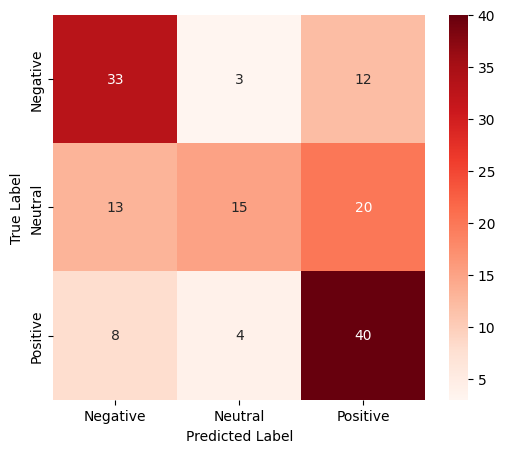

In [10]:
# Final Test
print("\n" + "="*30)
print("FINAL TEST EVALUATION")
print("="*30)

model_path = "/kaggle/working/multisentinet_best.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
else:
    model.eval()

model.load_state_dict(torch.load(Config.SAVE_PATH))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        images = batch['image'].to(Config.DEVICE)
        text = batch['text'].to(Config.DEVICE)
        labels = batch['label'].to(Config.DEVICE)
        
        logits = model(images, text)
        _, preds = torch.max(logits, 1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

print(classification_report(test_targets, test_preds, 
                            target_names=['Negative', 'Neutral', 'Positive'], zero_division=0,digits=6))
plot_confusion_matrix(test_targets, test_preds, "Final Test Confusion Matrix")

In [11]:
print("Success!")

Success!
